<a href="https://colab.research.google.com/github/gk2311/AIHC5020/blob/main/homework5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!pip install -q wfdb

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import csv
import xml.etree.ElementTree as ET
from pathlib import Path
import json
import requests
from datetime import datetime, date
import wfdb
from pathlib import Path

In [3]:
# Import the drive library from google.colab
from google.colab import drive

# Start the mounting process
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
# Initialization
wfdb_root = "/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb"
record_number = 101
max_duration = 15

# Problem 1

In [42]:
def load_ecg_data(record_number, max_duration, wfdb_root):

    if max_duration <= 0:
        raise ValueError("max_duration must be greater than 0 seconds.")

    #record_path = str(Path(wfdb_root) / str(record_number))
    #ecg_record = wfdb.rdrecord(record_path)
    #ecg_ann = wfdb.rdann(record_path, extension="atr")
    record_path = f'{wfdb_root}/{record_number}'
    ecg_record = wfdb.rdrecord(record_path)
    ecg_ann = wfdb.rdann(record_path, extension = 'atr')
    sample_rate = ecg_record.fs
    requested_cutoff = int(max_duration * sample_rate)

    cutoff_sample_index = min(requested_cutoff, len(ecg_record.p_signal))

    ecg_df = pd.DataFrame(
        data=ecg_record.p_signal[:cutoff_sample_index],
        columns=ecg_record.sig_name
    )

    annotations_df = pd.DataFrame({
        "annotation_index": ecg_ann.sample,
        "annotation_text": ecg_ann.symbol
    })

    annotations_df = (
        annotations_df[
            annotations_df["annotation_index"] < cutoff_sample_index
        ]
        .reset_index(drop=True)
    )

    return ecg_df, annotations_df, sample_rate

In [43]:
# Test Case
ecg_df, annotations_df, sample_rate = load_ecg_data(record_number=100, max_duration=10, wfdb_root=wfdb_root)

print("Sample rate:")
print(sample_rate)

print("\nLast 5 rows of the ECG DataFrame:")
display(ecg_df.tail())

print("\nLast 5 rows of the annotation DataFrame:")
display(annotations_df.tail())

Sample rate:
360

Last 5 rows of the ECG DataFrame:


,MLII,V5
3595,-0.385,-0.285
3596,-0.395,-0.285
3597,-0.390,-0.295
3598,-0.400,-0.290
3599,-0.405,-0.285



Last 5 rows of the annotation DataFrame:


,annotation_index,annotation_text
9,2402,N
10,2706,N
11,2998,N
12,3282,N
13,3560,N


In [44]:
# Challenge Case
ecg_df_101, annotations_df_101, sample_rate_101 = load_ecg_data(record_number=record_number, max_duration=max_duration, wfdb_root=wfdb_root)

In [45]:
print(ecg_df_101.tail())
print(annotations_df_101.tail())

       MLII     V1
5395 -0.275 -0.035
5396 -0.250 -0.015
5397 -0.245 -0.005
5398 -0.245  0.005
5399 -0.250  0.000
    annotation_index annotation_text
13              3960               N
14              4283               N
15              4609               N
16              4928               N
17              5241               N


# Problem 2

In [10]:
def plot_ecg_segment(ecg_df, annotations_df, channel_name, start_index, end_index):
    if channel_name not in ecg_df.columns:
        raise ValueError(
            f"'{channel_name}' not found. Available channels: "
            f"{list(ecg_df.columns)}"
        )

    ecg_window = ecg_df.loc[start_index:end_index]

    ann_window = annotations_df[
        (annotations_df["annotation_index"] >= start_index) &
        (annotations_df["annotation_index"] <= end_index)
    ]

    plt.figure(figsize=(20, 6))

    plt.plot(
        ecg_window.index,
        ecg_window[channel_name],
        color="blue",
        linewidth=1
    )

    y_max = ecg_window[channel_name].max()
    y_text = y_max + 0.05 * abs(y_max)

    for _, row in ann_window.iterrows():

        x = row["annotation_index"]
        label = row["annotation_text"]

        plt.axvline(
            x=x,
            color="red",
            linestyle="--",
            alpha=0.7
        )

        plt.text(
            x,
            y_text,
            label,
            color="red",
            fontsize=10,
            ha="center"
        )

    plt.title(
        f"ECG Segment ({channel_name}) "
        f"Samples {start_index}-{end_index}"
    )

    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude (mV)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [11]:
ecg_df_101, annotations_df_101, sample_rate = load_ecg_data(
    record_number=101,
    max_duration=30,
    wfdb_root=wfdb_root
)

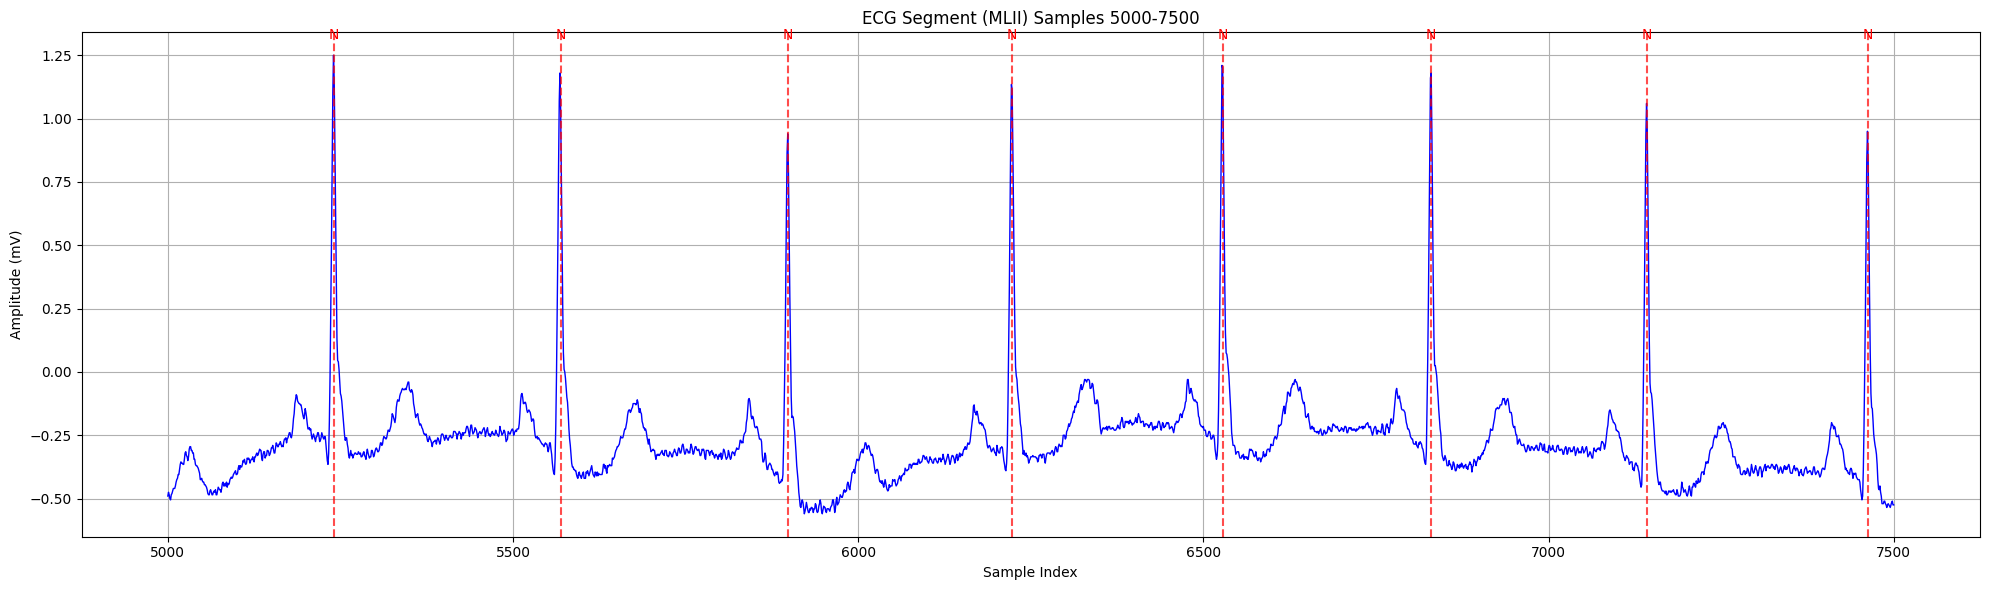

In [12]:
plot_ecg_segment(
    ecg_df=ecg_df_101,
    annotations_df=annotations_df_101,
    channel_name="MLII",
    start_index=5000,
    end_index=7500
)

In [13]:
ecg_df_103, annotations_df_103, sample_rate = load_ecg_data(
    record_number=103,
    max_duration=30,
    wfdb_root=wfdb_root
)

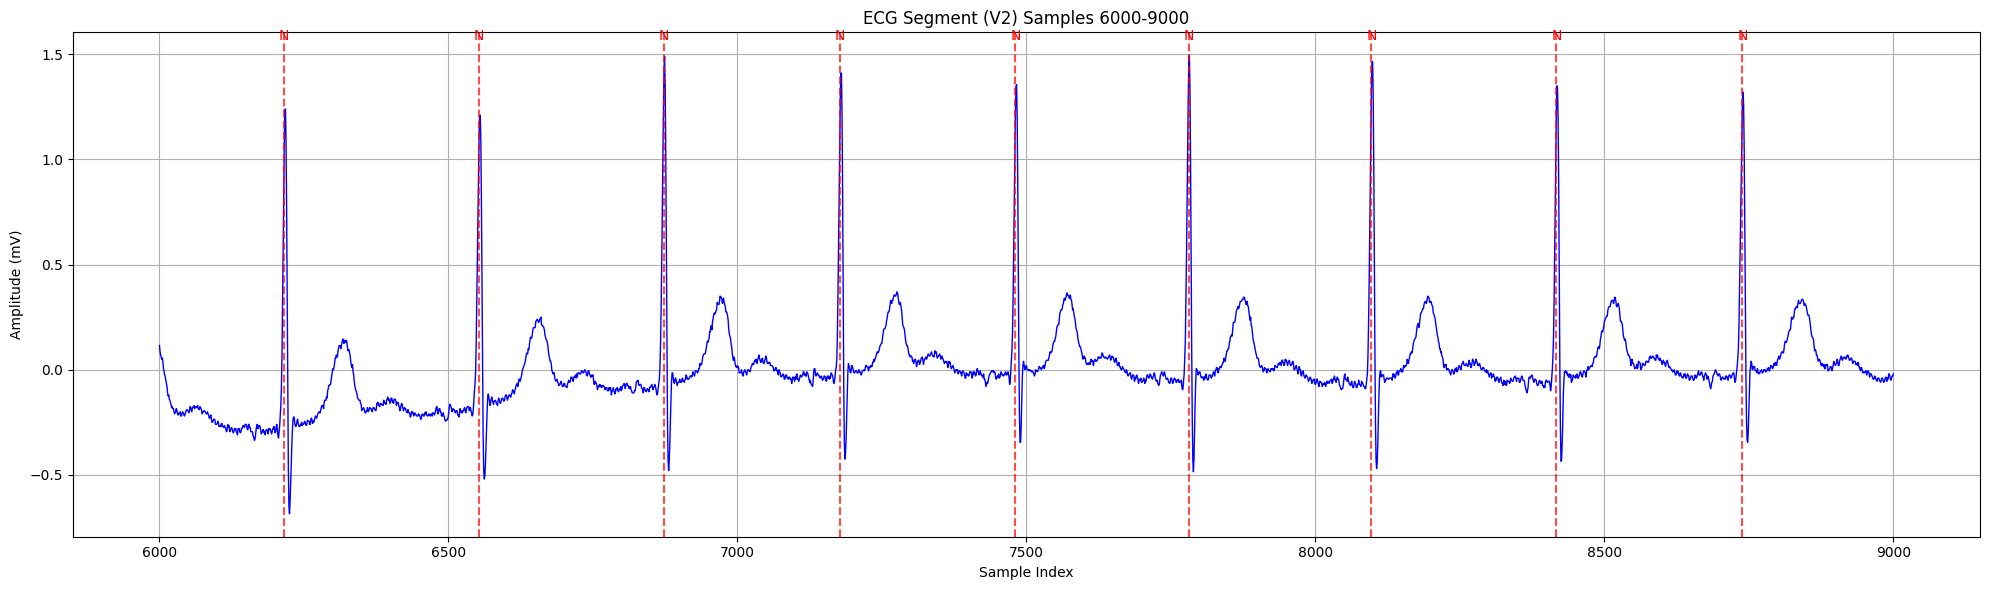

In [14]:
plot_ecg_segment(
    ecg_df=ecg_df_103,
    annotations_df=annotations_df_103,
    channel_name="V2",
    start_index=6000,
    end_index=9000
)

In [15]:
print(ecg_df_103.columns)

Index(['MLII', 'V2'], dtype='object')


In [16]:
annotations_df_103[
    (annotations_df_103["annotation_index"] >= 6000) &
    (annotations_df_103["annotation_index"] <= 9000)
]

,annotation_index,annotation_text
20,6216,N
21,6553,N
22,6873,N
23,7178,N
24,7481,N
25,7781,N
26,8097,N
27,8417,N
28,8739,N


In [17]:
def create_segment_table(
    record_number,
    max_duration,
    wfdb_root,
    segment_duration
):
    if max_duration <= 0:
        raise ValueError("max_duration must be greater than 0.")

    if segment_duration <= 0:
        raise ValueError("segment_duration must be greater than 0.")

    ecg_df, annotations_df, sample_rate = load_ecg_data(
        record_number=record_number,
        max_duration=max_duration,
        wfdb_root=wfdb_root
    )


    number_of_segments = int(
        np.ceil(max_duration / segment_duration)
    )


    data_segments = np.array_split(
        ecg_df.to_numpy(),
        number_of_segments
    )


    index_segments = np.array_split(
        ecg_df.index.to_numpy(),
        number_of_segments
    )

    segment_rows = []

    for segment_index, (data_segment, index_segment) in enumerate(
        zip(data_segments, index_segments)
    ):

        if len(index_segment) == 0:
            continue

        for channel_position, channel_name in enumerate(ecg_df.columns):

            channel_segment = data_segment[:, channel_position]

            segment_row = {
                "record_number": record_number,
                "segment_index": segment_index,
                "sample_rate": sample_rate,
                "n_samples": len(channel_segment),
                "channel_name": channel_name,
                "segment_start_index": int(index_segment[0]),
                "segment": channel_segment
            }

            segment_rows.append(segment_row)

    segment_table = pd.DataFrame(
        segment_rows,
        columns=[
            "record_number",
            "segment_index",
            "sample_rate",
            "n_samples",
            "channel_name",
            "segment_start_index",
            "segment"
        ]
    )

    return segment_table

In [18]:
wfdb_root = (
    "/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb"
)

segment_table_102 = create_segment_table(
    record_number=102,
    max_duration=30,
    wfdb_root=wfdb_root,
    segment_duration=4
)

segment_table_102.head()

,record_number,segment_index,sample_rate,n_samples,channel_name,segment_start_index,segment
0,102,0,360,1350,V5,0,"[-0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0...."
1,102,0,360,1350,V2,0,"[0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.0..."
2,102,1,360,1350,V5,1350,"[-0.41, -0.4, -0.385, -0.37, -0.34, -0.305, -0..."
3,102,1,360,1350,V2,1350,"[-2.465, -2.285, -2.11, -1.905, -1.67, -1.425,..."
4,102,2,360,1350,V5,2700,"[-0.225, -0.23, -0.24, -0.245, -0.255, -0.25, ..."


In [19]:
print(segment_table_102.head())

   record_number  segment_index  sample_rate  n_samples channel_name  \
0            102              0          360       1350           V5   
1            102              0          360       1350           V2   
2            102              1          360       1350           V5   
3            102              1          360       1350           V2   
4            102              2          360       1350           V5   

   segment_start_index                                            segment  
0                    0  [-0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0....  
1                    0  [0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.0...  
2                 1350  [-0.41, -0.4, -0.385, -0.37, -0.34, -0.305, -0...  
3                 1350  [-2.465, -2.285, -2.11, -1.905, -1.67, -1.425,...  
4                 2700  [-0.225, -0.23, -0.24, -0.245, -0.255, -0.25, ...  


In [20]:
np.ceil(30 / 4)

np.float64(8.0)

In [21]:
print("Segment table shape:")
print(segment_table_102.shape)

print("\nColumn names:")
print(segment_table_102.columns.tolist())

print("\nNumber of segments:")
print(segment_table_102["segment_index"].nunique())

print("\nChannels:")
print(segment_table_102["channel_name"].unique())

print("\nSamples per segment:")
print(
    segment_table_102[
        ["segment_index", "n_samples", "segment_start_index"]
    ].drop_duplicates()
)

Segment table shape:
(16, 7)

Column names:
['record_number', 'segment_index', 'sample_rate', 'n_samples', 'channel_name', 'segment_start_index', 'segment']

Number of segments:
8

Channels:
['V5' 'V2']

Samples per segment:
    segment_index  n_samples  segment_start_index
0               0       1350                    0
2               1       1350                 1350
4               2       1350                 2700
6               3       1350                 4050
8               4       1350                 5400
10              5       1350                 6750
12              6       1350                 8100
14              7       1350                 9450


In [22]:
print(segment_table_102.loc[0, "segment"])

[-0.2   -0.2   -0.2   ... -0.445 -0.45  -0.43 ]


In [23]:
!pip install -q pydicom

In [24]:
import pandas as pd
import pydicom
from pathlib import Path

In [25]:
def create_dicom_manifest(root_dir: str):

    root_dir = Path(root_dir)
    manifest_rows = []

    # Traverse all subdirectories
    for folder in root_dir.rglob("*"):

        if not folder.is_dir():
            continue

        # Find DICOM files in this folder
        dicom_files = list(folder.glob("*.dcm"))

        # Skip folders that are not series folders
        if len(dicom_files) == 0:
            continue

        n_images = len(dicom_files)

        try:
            # Read a single representative file
            ds = pydicom.dcmread(
                dicom_files[0],
                stop_before_pixels=True
            )

            row = {
                "patient_id":
                    ds.get("PatientID", "N/A"),

                "study_date":
                    ds.get("StudyDate", "N/A"),

                "modality":
                    ds.get("Modality", "N/A"),

                "study_description":
                    ds.get("StudyDescription", "N/A"),

                "series_description":
                    ds.get("SeriesDescription", "N/A"),

                "n_images":
                    n_images,

                "study_instance_uid":
                    ds.get("StudyInstanceUID", "N/A"),

                "series_instance_uid":
                    ds.get("SeriesInstanceUID", "N/A"),

                "series_path":
                    str(folder)
            }

            manifest_rows.append(row)

        except Exception as e:

            print(
                f"Could not read "
                f"{dicom_files[0]}: {e}"
            )

            continue

    manifest_df = pd.DataFrame(manifest_rows)

    return manifest_df

In [26]:
dicom_root = (
    "/content/drive/MyDrive/AIHC5020/"
    "dicom/tcia/LIDC-IDRI"
)

manifest_df = create_dicom_manifest(
    dicom_root
)

In [27]:
manifest_df.head()

,patient_id,study_date,modality,study_description,series_description,n_images,study_instance_uid,series_instance_uid,series_path
0,LIDC-IDRI-0001,20000101,CT,N/A,N/A,133,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
1,LIDC-IDRI-0001,20000101,SR,N/A,Nodule 1 - Annotation Nodule 001 evaluations,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.2.276.0.7230010.3.1.3.0.89315.1553284069.532969,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
2,LIDC-IDRI-0001,20000101,SEG,N/A,Segmentation of Nodule 1 - Annotation 0,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.2.276.0.7230010.3.1.3.0.89358.1553284079.860324,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
3,LIDC-IDRI-0001,20000101,SEG,N/A,Segmentation of Nodule 1 - Annotation Nodule 001,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.2.276.0.7230010.3.1.3.0.89314.1553284067.990548,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
4,LIDC-IDRI-0001,20000101,SEG,N/A,Segmentation of Nodule 1 - Annotation MI014_12127,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.2.276.0.7230010.3.1.3.0.89355.1553284075.626419,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...


In [28]:
ct_manifest = manifest_df[
    manifest_df["modality"] == "CT"
]

ct_manifest

,patient_id,study_date,modality,study_description,series_description,n_images,study_instance_uid,series_instance_uid,series_path
0,LIDC-IDRI-0001,20000101,CT,N/A,N/A,133,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
10,LIDC-IDRI-0002,20000101,CT,N/A,N/A,261,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
16,LIDC-IDRI-0005,20000101,CT,N/A,N/A,133,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,1.3.6.1.4.1.14519.5.2.1.6279.6001.129007566048...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
46,LIDC-IDRI-0003,20000101,CT,N/A,N/A,140,1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
69,LIDC-IDRI-0004,20000101,CT,N/A,N/A,241,1.3.6.1.4.1.14519.5.2.1.6279.6001.191425307197...,1.3.6.1.4.1.14519.5.2.1.6279.6001.323541312620...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
77,LIDC-IDRI-0006,20000101,CT,N/A,N/A,133,1.3.6.1.4.1.14519.5.2.1.6279.6001.324680252006...,1.3.6.1.4.1.14519.5.2.1.6279.6001.132817748896...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...


In [29]:
ct_manifest[
    [
        "patient_id",
        "study_date",
        "series_description",
        "n_images",
        "series_path"
    ]
]

,patient_id,study_date,series_description,n_images,series_path
0,LIDC-IDRI-0001,20000101,N/A,133,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
10,LIDC-IDRI-0002,20000101,N/A,261,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
16,LIDC-IDRI-0005,20000101,N/A,133,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
46,LIDC-IDRI-0003,20000101,N/A,140,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
69,LIDC-IDRI-0004,20000101,N/A,241,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
77,LIDC-IDRI-0006,20000101,N/A,133,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...


In [30]:
manifest_df["modality"].value_counts()

,count
modality,
SR,40
SEG,40
CT,6
DX,5
CR,1


In [31]:
len(
    manifest_df[
        manifest_df["modality"] == "CT"
    ]
)

6

In [32]:
manifest_df.loc[
    manifest_df["modality"] == "CT",
    ["patient_id", "n_images"]
]

,patient_id,n_images
0,LIDC-IDRI-0001,133
10,LIDC-IDRI-0002,261
16,LIDC-IDRI-0005,133
46,LIDC-IDRI-0003,140
69,LIDC-IDRI-0004,241
77,LIDC-IDRI-0006,133


In [33]:
manifest_df[
    manifest_df["modality"] == "CT"
].head(1)

,patient_id,study_date,modality,study_description,series_description,n_images,study_instance_uid,series_instance_uid,series_path
0,LIDC-IDRI-0001,20000101,CT,N/A,N/A,133,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...


In [34]:
manifest_df[manifest_df["modality"] == "CT"]

,patient_id,study_date,modality,study_description,series_description,n_images,study_instance_uid,series_instance_uid,series_path
0,LIDC-IDRI-0001,20000101,CT,N/A,N/A,133,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
10,LIDC-IDRI-0002,20000101,CT,N/A,N/A,261,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
16,LIDC-IDRI-0005,20000101,CT,N/A,N/A,133,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,1.3.6.1.4.1.14519.5.2.1.6279.6001.129007566048...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
46,LIDC-IDRI-0003,20000101,CT,N/A,N/A,140,1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
69,LIDC-IDRI-0004,20000101,CT,N/A,N/A,241,1.3.6.1.4.1.14519.5.2.1.6279.6001.191425307197...,1.3.6.1.4.1.14519.5.2.1.6279.6001.323541312620...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
77,LIDC-IDRI-0006,20000101,CT,N/A,N/A,133,1.3.6.1.4.1.14519.5.2.1.6279.6001.324680252006...,1.3.6.1.4.1.14519.5.2.1.6279.6001.132817748896...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...


In [35]:
import numpy as np
import pydicom
import matplotlib.pyplot as plt
from pathlib import Path


def visualize_ct_series(manifest_row):
    """
    Display a 4-slice montage from a CT series.

    Parameters
    ----------
    manifest_row : pd.Series
        One row from the DICOM manifest.
    """

    # -----------------------------------
    # Validate input
    # -----------------------------------
    if manifest_row["modality"] != "CT":
        raise ValueError(
            "Function only supports CT series."
        )

    if manifest_row["n_images"] <= 1:
        raise ValueError(
            "Series must contain more than 1 image."
        )

    series_path = Path(manifest_row["series_path"])

    # -----------------------------------
    # Load all DICOM files
    # -----------------------------------
    dicom_files = list(series_path.glob("*.dcm"))

    slices = []

    for fp in dicom_files:

        try:
            ds = pydicom.dcmread(fp)

            instance_number = ds.get(
                "InstanceNumber",
                0
            )

            slices.append(
                (instance_number, ds)
            )

        except Exception:
            continue

    if len(slices) == 0:
        raise ValueError(
            "No valid DICOM slices found."
        )

    # -----------------------------------
    # Sort by InstanceNumber
    # -----------------------------------
    slices.sort(key=lambda x: x[0])

    sorted_slices = [x[1] for x in slices]

    n = len(sorted_slices)

    # -----------------------------------
    # Select slices at
    # 20%, 40%, 60%, 80%
    # -----------------------------------
    selected_indices = [
        int(n * 0.2),
        int(n * 0.4),
        int(n * 0.6),
        int(n * 0.8)
    ]

    # Prevent index overflow
    selected_indices = [
        min(i, n - 1)
        for i in selected_indices
    ]

    # -----------------------------------
    # Create montage
    # -----------------------------------
    fig, axes = plt.subplots(
        1,
        4,
        figsize=(16, 4)
    )

    for ax, idx in zip(
        axes,
        selected_indices
    ):

        ds = sorted_slices[idx]

        ax.imshow(
            ds.pixel_array,
            cmap="gray"
        )

        ax.set_title(
            f"Slice {ds.get('InstanceNumber', idx)}"
        )

        ax.set_axis_off()

    fig.suptitle(
        f"Patient: {manifest_row['patient_id']} | "
        f"Study Date: {manifest_row['study_date']}",
        fontsize=14
    )

    plt.tight_layout()

    plt.show()

In [36]:
ct_manifest = manifest_df[
    manifest_df["modality"] == "CT"
]

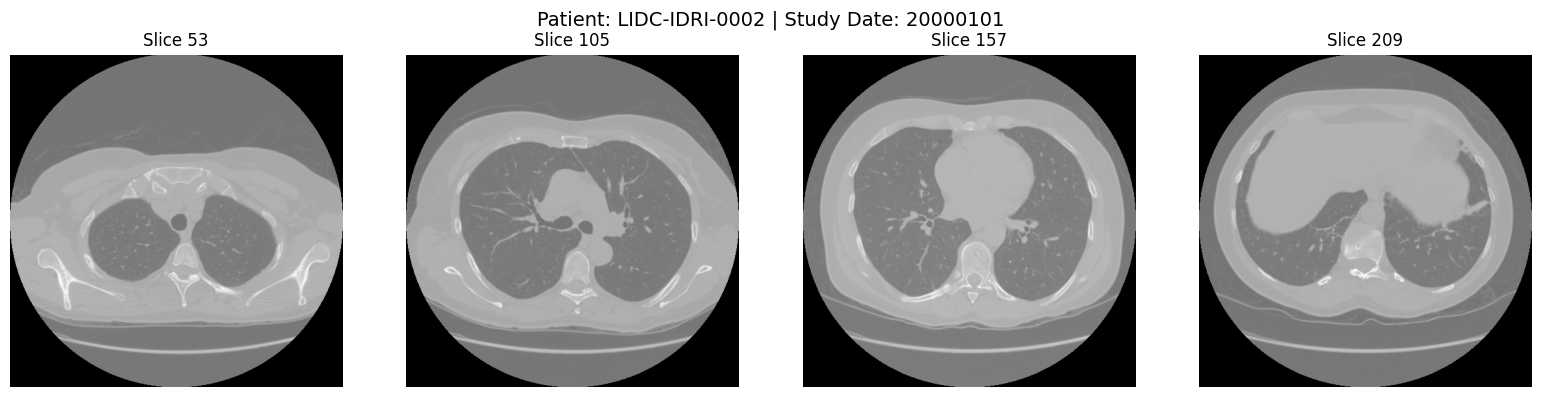

In [37]:
row_0002 = ct_manifest[
    ct_manifest["patient_id"] == "LIDC-IDRI-0002"
].iloc[0]

visualize_ct_series(row_0002)

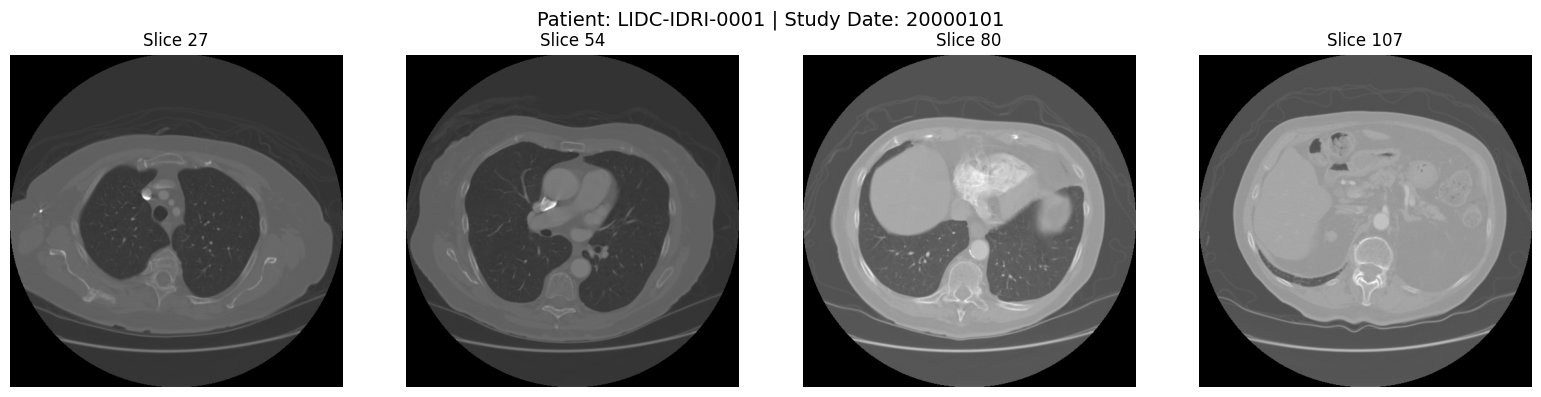

In [38]:
ct_manifest = manifest_df[
    manifest_df["modality"] == "CT"
]

row_0001 = ct_manifest[
    ct_manifest["patient_id"] == "LIDC-IDRI-0001"
].iloc[0]

visualize_ct_series(row_0001)

In [39]:
row_0001[
    [
        "patient_id",
        "study_date",
        "modality",
        "n_images",
        "series_path"
    ]
]

,0
patient_id,LIDC-IDRI-0001
study_date,20000101
modality,CT
n_images,133
series_path,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...


In [40]:
n = row_0001["n_images"]

print(int(n * 0.2))
print(int(n * 0.4))
print(int(n * 0.6))
print(int(n * 0.8))

26
53
79
106
